<a href="https://colab.research.google.com/github/Limsungrae/Hongong/blob/main/%ED%98%BC%EA%B3%B5%EB%A8%B8%EC%8B%A0_9_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### LSTML과 GRU *셀*

In [1]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras
import tensorflow as tf

# 결과 재현 (항상 같은 결과)
keras.utils.set_random_seed(42)
tf.random.set_seed(42)

# 연산 동일하게 유지
tf.config.experimental.enable_op_determinism()

#### LSTM 신경망 훈련하기

In [2]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 문장 길이를 맞추기 위한 패딩 처리
from keras.preprocessing.sequence import pad_sequences

# maxlen=100 → 문장을 길이 100으로 맞춤
# 짧으면 앞쪽에 0으로 채움 / 길면 앞부분 잘림
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [5]:
model_lstm = keras.Sequential()

# 입력: 단어 100개
model_lstm.add(keras.layers.Input(shape=(100,)))

# 단어 → 벡터 변환 (임베딩)
model_lstm.add(keras.layers.Embedding(500, 16))

# LSTM (기억하는 신경망)
model_lstm.add(keras.layers.LSTM(8))

# 출력 (긍정/부정)
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [6]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 모델 학습 설정
model_lstm.compile(
    optimizer='adam',               # 자동으로 학습률 조정해주는 최적화 알고리즘
    loss='binary_crossentropy',     # 이진 분류용 손실 함수
    metrics=['accuracy']            # 평가 지표 (정확도)
)
# 가장 성능 좋은 모델만 저장하는 콜백
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-lstm-model.keras',  # 저장 파일명
    save_best_only=True       # 최고 성능일 때만 저장
)
# 조기 종료 콜백 (과적합 방지)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,               # 3번 연속 성능 개선 없으면 중단
    restore_best_weights=True # 가장 좋은 시점의 가중치로 복원
)
# 모델 학습 시작
history = model_lstm.fit(
    train_seq, train_target,          # 훈련 데이터
    epochs=100,                       # 최대 100번 반복
    batch_size=64,                    # 한 번에 64개씩 학습
    validation_data=(val_seq, val_target),  # 검증 데이터
    callbacks=[checkpoint_cb, early_stopping_cb]  # 콜백 적용
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step - accuracy: 0.6858 - loss: 0.5886 - val_accuracy: 0.7706 - val_loss: 0.4941
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.7865 - loss: 0.4719 - val_accuracy: 0.7874 - val_loss: 0.4652
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 199ms/step - accuracy: 0.8019 - loss: 0.4440 - val_accuracy: 0.7826 - val_loss: 0.4647
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.8037 - loss: 0.4378 - val_accuracy: 0.7854 - val_loss: 0.4533
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 208ms/step - accuracy: 0.8276 - loss: 0.3988 - val_accuracy: 0.7868 - val_loss: 0.4455
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 197ms/step - accuracy: 0.8369 - loss: 0.3824 - val_accuracy: 0.7998 - val_loss: 0.4364
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 203ms/step - accuracy: 0.8400 - loss: 0.3729 - val_accuracy: 0.7960 - val_loss: 0.4368
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 203ms/step - accuracy: 0.8371 -

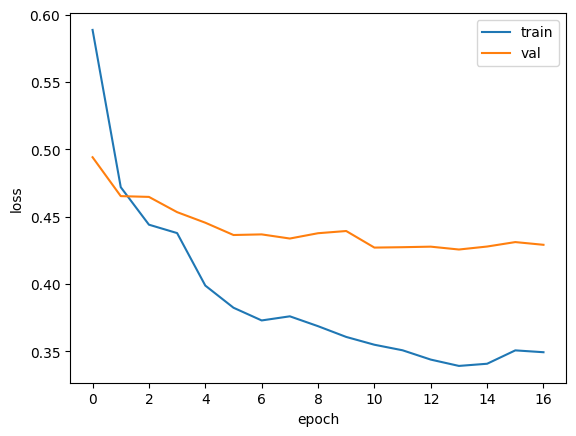

In [9]:
import matplotlib.pyplot as plt

# 훈련 손실(loss) 그래프
plt.plot(history.history['loss'], label='train')

# 검증 손실(loss) 그래프
plt.plot(history.history['val_loss'], label='val')

# x축: epoch (학습 반복 횟수)
plt.xlabel('epoch')

# y축: loss (오차)
plt.ylabel('loss')

# 범례 표시
plt.legend()

# 그래프 출력
plt.show()

### LSTM + Dropout (과적합 방지)

In [10]:
# 새로운 모델 생성
model_dropout = keras.Sequential()

# 입력층 (길이 100 문장)
model_dropout.add(keras.layers.Input(shape=(100,)))

# 임베딩 (단어 → 16차원 벡터)
model_dropout.add(keras.layers.Embedding(500, 16))

# LSTM + dropout
# dropout=0.2 → 학습 중 20% 뉴런 랜덤 제거 (과적합 방지)
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))

# 출력층 (이진 분류)
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [11]:
# 학습 설정
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# 최고 성능 모델 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-dropout-model.keras',
    save_best_only=True
)

# 성능 향상 없으면 조기 종료
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)
# 학습 실행
history = model_dropout.fit(
    train_seq, train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 209ms/step - accuracy: 0.6536 - loss: 0.6270 - val_accuracy: 0.7312 - val_loss: 0.5621
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step - accuracy: 0.7380 - loss: 0.5371 - val_accuracy: 0.7612 - val_loss: 0.4994
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 213ms/step - accuracy: 0.7639 - loss: 0.4982 - val_accuracy: 0.7698 - val_loss: 0.4827
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 209ms/step - accuracy: 0.7478 - loss: 0.5227 - val_accuracy: 0.7822 - val_loss: 0.4772
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 208ms/step - accuracy: 0.8023 - loss: 0.4449 - val_accuracy: 0.7884 - val_loss: 0.4618
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.7990 - loss: 0.4493 - val_accuracy: 0.5732 - val_loss: 0.6917
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 207ms/step - accuracy: 0.7498 - loss: 0.5052 - val_accuracy: 0.7898 - val_loss: 0.4505
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 209ms/step - accuracy: 0.8219 -

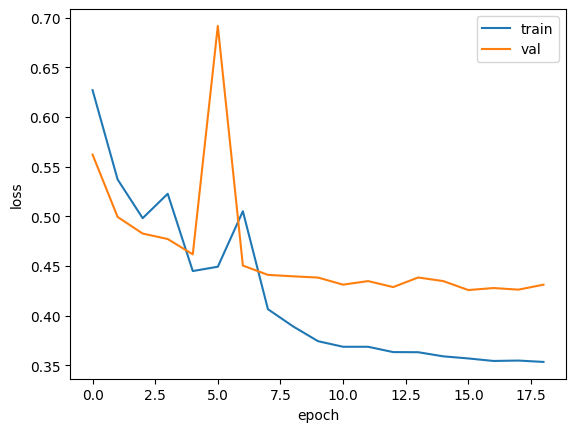

In [12]:
# 결과 그래프
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### GRU 모델 (LSTM 대체)

In [13]:
# GRU 모델 생성
model_gru = keras.Sequential()

# 입력
model_gru.add(keras.layers.Input(shape=(100,)))

# 임베딩
model_gru.add(keras.layers.Embedding(500, 16))

# GRU (LSTM보다 간단하고 빠름)
model_gru.add(keras.layers.GRU(8, dropout=0.2))

# 출력
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

In [14]:
# 구조 확인
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 컴파일
model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# 콜백 설정
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-gru-model.keras',
    save_best_only=True
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)
# 학습
history = model_gru.fit(
    train_seq, train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 273ms/step - accuracy: 0.6345 - loss: 0.6290 - val_accuracy: 0.6964 - val_loss: 0.5779
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - accuracy: 0.7642 - loss: 0.5045 - val_accuracy: 0.7324 - val_loss: 0.5381
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 277ms/step - accuracy: 0.7761 - loss: 0.4832 - val_accuracy: 0.7452 - val_loss: 0.5227
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accuracy: 0.7880 - loss: 0.4684 - val_accuracy: 0.7714 - val_loss: 0.4774
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 273ms/step - accuracy: 0.8011 - loss: 0.4416 - val_accuracy: 0.7936 - val_loss: 0.4510
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 276ms/step - accuracy: 0.8051 - loss: 0.4323 - val_accuracy: 0.7904 - val_loss: 0.4490
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 271ms/step - accuracy: 0.8247 - loss: 0.3991 - val_accuracy: 0.7902 - val_loss: 0.4509
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 271ms/step - accuracy: 0.837

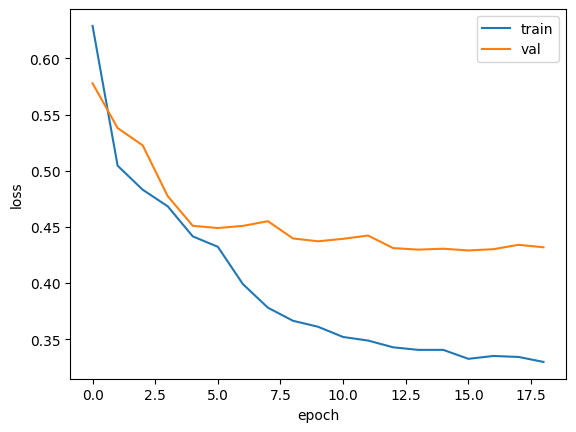

In [16]:
# 결과 그래프
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### 4. 최종 테스트 평가

In [17]:
# 테스트 데이터도 동일하게 길이 맞춤
test_seq = pad_sequences(test_input, maxlen=100)

# 가장 성능 좋은 GRU 모델 불러오기
best_model = keras.models.load_model('best-gru-model.keras')

# 테스트 정확도 평가 (최종 성능)
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8089 - loss: 0.4178


[0.4178372621536255, 0.8089200258255005]